# Comparison of Logistic Regression and K Nearest Neighbors (KNN) Classifiers

## IMPORTING NECESSARY LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

sns.set(style="whitegrid")

## LOADING THE DATASET

In [2]:
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target   # 0 = malignant, 1 = benign

print(df.shape)
df.head()

(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## EDA

In [3]:
df.info()
print("\nClass distribution:\n", df['target'].value_counts())
print("\nTarget names:", data.target_names)

print("\nMissing values per column:\n", df.isnull().sum().sum(), "total missing values")

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


## VIZUALIZING CLASS IMBALANCE

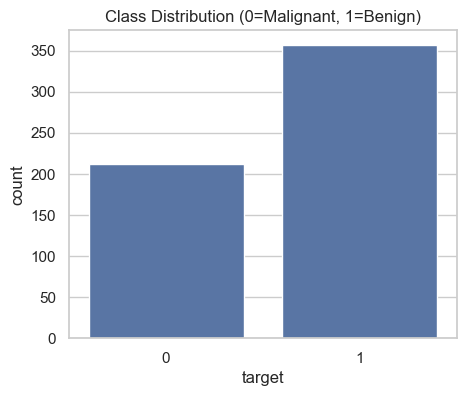

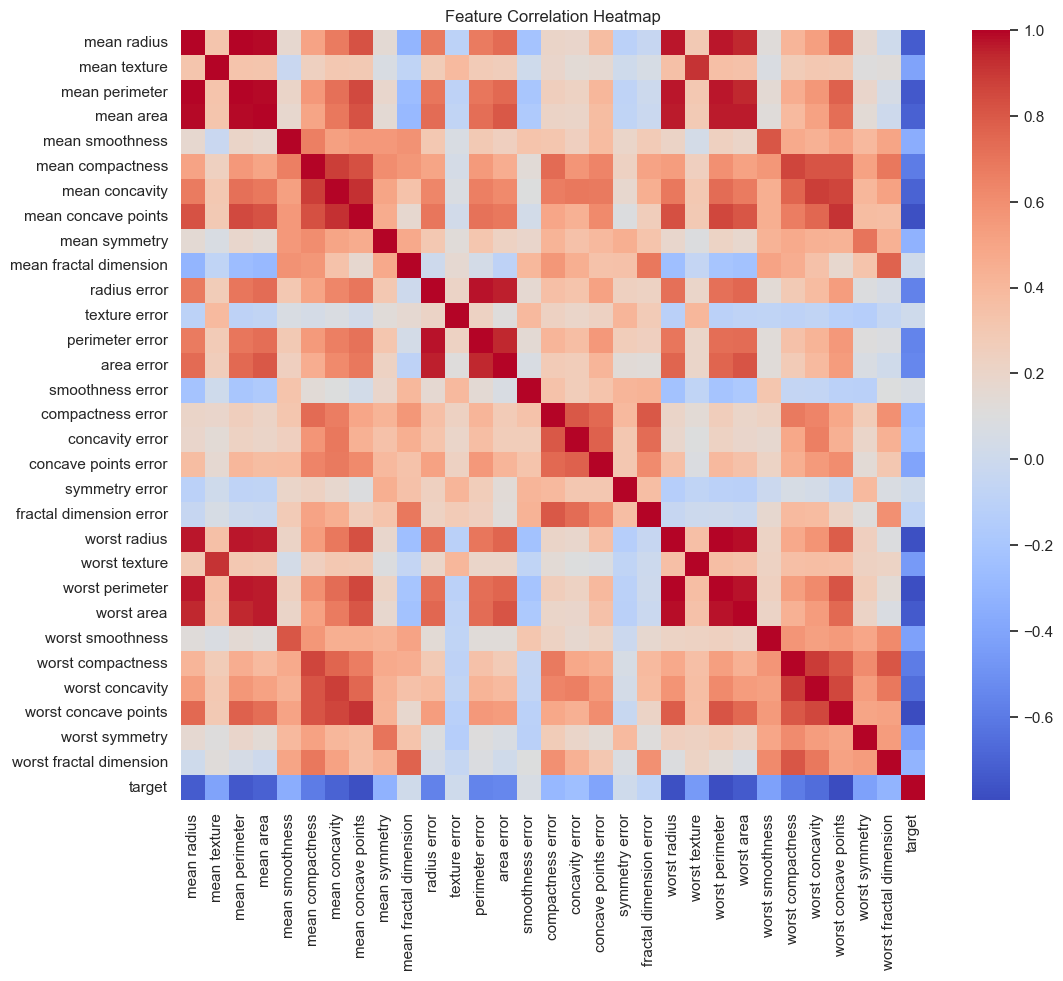

In [4]:
plt.figure(figsize=(5,4))
sns.countplot(x='target', data=df)
plt.title("Class Distribution (0=Malignant, 1=Benign)")
plt.show()

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

## PREPROCESSING : TRAIN TEST SPLIT + SCALING

In [5]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train_scaled.shape)
print("Testing set size:", X_test_scaled.shape)

Training set size: (455, 30)
Testing set size: (114, 30)


## TRAINING LOGISTIC REGRESSION

In [6]:
log_reg = LogisticRegression(max_iter=10000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

## TRAINING KNN

In [7]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

## EVALUATION FUNCTION

In [8]:
def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"--- {model_name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print("Confusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

    return {"Model": model_name, "Accuracy": acc, "Precision": prec,
            "Recall": rec, "F1 Score": f1, "Confusion Matrix": cm}

results_lr = evaluate_model(y_test, y_pred_lr, "Logistic Regression")

--- Logistic Regression ---
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1 Score : 0.9861
Confusion Matrix:
 [[41  1]
 [ 1 71]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## EVALUATING KNN

In [9]:
results_knn = evaluate_model(y_test, y_pred_knn, "K Nearest Neighbors")

--- K Nearest Neighbors ---
Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1 Score : 0.9655
Confusion Matrix:
 [[39  3]
 [ 2 70]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## CONFUSION MATRIX HEATMAP

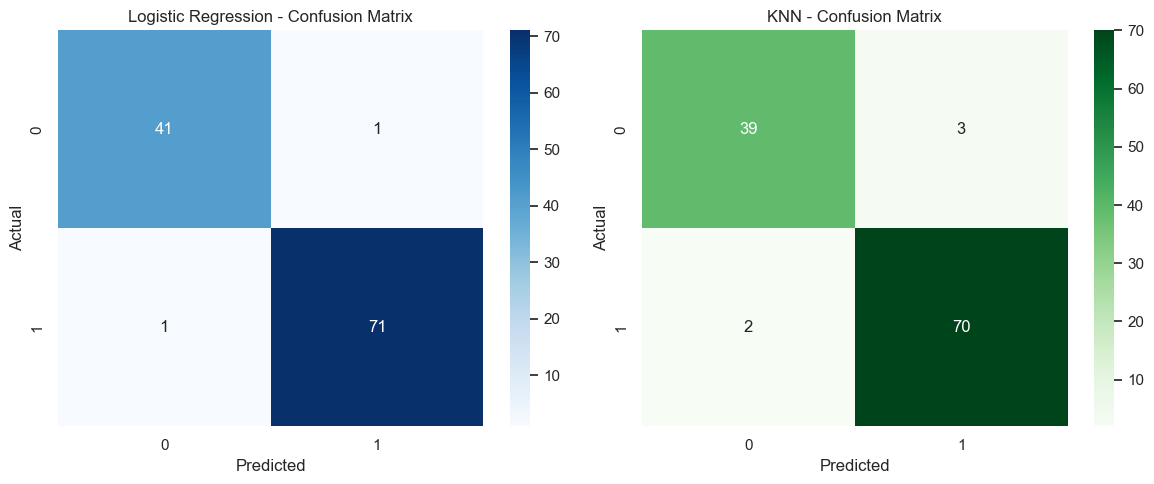

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(results_lr["Confusion Matrix"], annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Logistic Regression - Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(results_knn["Confusion Matrix"], annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("KNN - Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

## COMPARISON TABLE

In [11]:
comparison_df = pd.DataFrame([
    {"Model": "Logistic Regression",
     "Accuracy": results_lr["Accuracy"],
     "Precision": results_lr["Precision"],
     "Recall": results_lr["Recall"],
     "F1 Score": results_lr["F1 Score"]},
    {"Model": "K Nearest Neighbors",
     "Accuracy": results_knn["Accuracy"],
     "Precision": results_knn["Precision"],
     "Recall": results_knn["Recall"],
     "F1 Score": results_knn["F1 Score"]}
])

comparison_df.set_index("Model", inplace=True)
comparison_df

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.982456,0.986111,0.986111,0.986111
K Nearest Neighbors,0.956140,0.958904,0.972222,0.965517


## BAR CHART COMPARISON

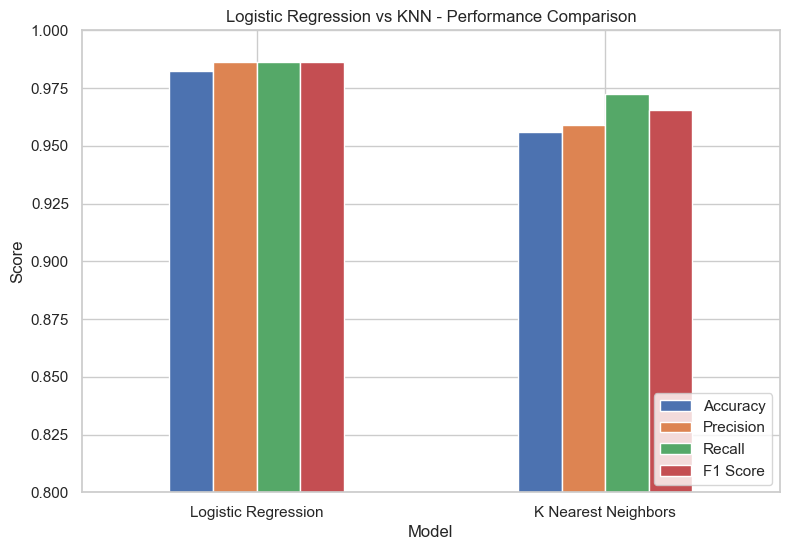

In [12]:
comparison_df.plot(kind='bar', figsize=(9,6))
plt.title("Logistic Regression vs KNN - Performance Comparison")
plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

## INTERPRETATION

- Both classifiers perform strongly on this dataset because the features are highly separable between malignant and benign classes
- Logistic Regression typically performs slightly better or comparably here because the decision boundary between classes is close to linear once features are scaled.
- KNN's performance depends heavily on the choice of k and on feature scaling, without scaling, KNN would perform poorly since features like "area" have much larger numeric ranges than features like "smoothness".
- In a medical diagnosis context, Recall for the malignant class is especially important, since missing a malignant case (false negative) is more costly than a false positive.

## FINDING OPTIMAL K VALUE

Best k found: 7 with CV accuracy: 0.9737


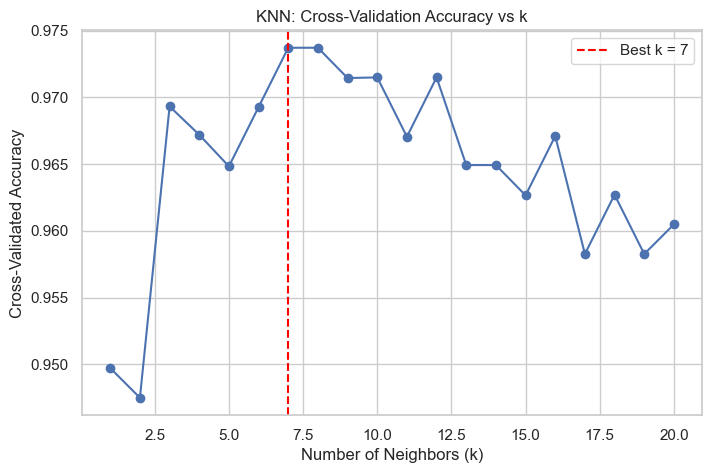

In [13]:
from sklearn.model_selection import cross_val_score

k_values = range(1, 21)
cv_scores = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_temp, X_train_scaled, y_train, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k = k_values[np.argmax(cv_scores)]
print(f"Best k found: {best_k} with CV accuracy: {max(cv_scores):.4f}")

plt.figure(figsize=(8,5))
plt.plot(k_values, cv_scores, marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
plt.title("KNN: Cross-Validation Accuracy vs k")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Cross-Validated Accuracy")
plt.legend()
plt.show()

In [14]:
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred_knn_best = knn_best.predict(X_test_scaled)

results_knn_best = evaluate_model(y_test, y_pred_knn_best, f"KNN (k={best_k}, tuned)")

--- KNN (k=7, tuned) ---
Accuracy : 0.9737
Precision: 0.9600
Recall   : 1.0000
F1 Score : 0.9796
Confusion Matrix:
 [[39  3]
 [ 0 72]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.96        42
           1       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



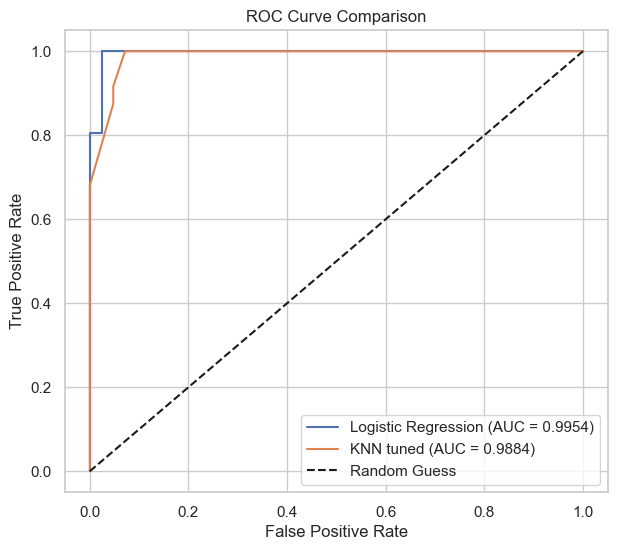

Logistic Regression AUC: 0.9954
Tuned KNN AUC: 0.9884


In [15]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predicted probabilities for benign = 1
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
y_prob_knn = knn_best.predict_proba(X_test_scaled)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)

auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_knn = roc_auc_score(y_test, y_prob_knn)

plt.figure(figsize=(7,6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.4f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN tuned (AUC = {auc_knn:.4f})")
plt.plot([0,1], [0,1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

print(f"Logistic Regression AUC: {auc_lr:.4f}")
print(f"Tuned KNN AUC: {auc_knn:.4f}")

In [16]:
final_comparison = pd.DataFrame([
    {"Model": "Logistic Regression", "Accuracy": results_lr["Accuracy"],
     "Precision": results_lr["Precision"], "Recall": results_lr["Recall"],
     "F1 Score": results_lr["F1 Score"], "AUC": auc_lr},
    {"Model": "KNN (k=5, default)", "Accuracy": results_knn["Accuracy"],
     "Precision": results_knn["Precision"], "Recall": results_knn["Recall"],
     "F1 Score": results_knn["F1 Score"], "AUC": np.nan},
    {"Model": f"KNN (k={best_k}, tuned)", "Accuracy": results_knn_best["Accuracy"],
     "Precision": results_knn_best["Precision"], "Recall": results_knn_best["Recall"],
     "F1 Score": results_knn_best["F1 Score"], "AUC": auc_knn},
])

final_comparison.set_index("Model", inplace=True)
final_comparison

,Accuracy,Precision,Recall,F1 Score,AUC
Model,,,,,
Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.995370
"KNN (k=5, default)",0.956140,0.958904,0.972222,0.965517,NaN
"KNN (k=7, tuned)",0.973684,0.960000,1.000000,0.979592,0.988426
